# Постановка задачи


**Цель работы:** исследование и обработка данных для повышения их качества.

**Краткое описание:** в лабораторной работе приводится поэтапный план изучения и обработки намеренно не предобработанных данных. Необходимо выполнить все этапы плана и оценить результаты преобразований.

# Данные



В папке [Data/lab3](https://drive.google.com/drive/folders/1437z7m5Ut4WUJOhJg1oZz13dtBpxgFKs?usp=share_link) расположена таблица `monster_com_job_sample.com` с данными о вакансиях. Также эти данные с описанием и примерами обработки можно найти на [kaggle](https://www.kaggle.com/code/ankkur13/perfect-dataset-to-get-the-hands-dirty/data#).

##### **Формат данных**

```
country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
United States of America,US,"",No,jobs.monster.com,"TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the field's concepts, practices, and procedures as this position relies on extensive experience and judgment to plan and accomplish goals. Required Skills:вАҐ Call tracking softwareвАҐ Phone based technical supportвАҐ Problem documentation and communicationвАҐ Remote Desktop Management ToolsвАҐ Respond to customer requestsвАҐ General understanding of LANDeskвАҐ Microsoft Office 2007 SuiteFind out why TeamSoft is the Madison area's technology leader with over 200 IT consultants. Owned, operated, and managed by IT consultants, TeamSoft is the clear choice for your career. Join the TeamSoft family today!Did you know?вАҐ TeamSoft offers salaried options for many positions that include 5 weeks PTO and great benefits!вАҐ TeamSoft has been in business since 1996вАҐ TeamSoft's owners are local IT professionals who possess a wealth of experience in application development, business analysis, and project managementвАҐ TeamSoft's Recruiters are knowledgeable, friendly, and ready to help you make your next great career moveвАҐ TeamSoft offers a full benefits suite to all of our W2 consultants, including a 401k plan with a 100% vested 4% dollar for dollar matchвАҐ Our targeted selection process is designed to get to know your strengths and career interests and provide you with the best chance for success in your new positionвАҐ Our longest running consultant has been with us for 16 yearsвАҐ Consultants can participate in our charitable giving committee. To date, TeamSoft's charitable giving committee has donated over $100,000!TeamSoft is owned by local IT professionals. Our team also has deep experience with IT staffing. Our clients understand this and rely on our expertise. That is why TeamSoft is the Madison Area's largest privately owned IT consulting firm, with more than 200 current consultants! With over 50 active clients, TeamSoft will give you the greatest exposure to the widest range of IT careers.Our owners possess a combined 60+ years of IT consulting experience. Our recruiting and Account Management staff are very well-versed in our client markets. We get you. We know you. We know what you do every day. And we know what you deal with on the job.You take your career seriously and so do we. At TeamSoft you are not just a resume or number. Our goal is to create long-term partnerships with each of our consultants, and according to feedback from many of them, we are very good at this. Click HERE to see what our consultants have to say about working with TeamSoft.TeamSoft -- Promote yourself!TeamSoft is an equal employment opportunity employer functioning under an Affirmative Action Plan.",IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702","",http://jobview.monster.com/it-support-technician-job-madison-wi-us-167855963.aspx?mescoid=1500134001001&jobPosition=20,"",IT/Software Development,11d599f229a80023d2f40e7c52cd941e
United States of America,US,"",No,jobs.monster.com,"The Wisconsin State Journal is seeking a flexible and motivated reporter/editor to lead its three-person business desk. WeвАЩre looking for an experienced journalist able to spot trends, be a watchdog and reflect the Madison areaвАЩs vibrant entrepreneurial community. This is a hybrid reporting and editing position that calls for a fleet-footed, multimedia storyteller able to maximize the newspaperвАЩs online presentation while also editing two sections a week. Candidates must have strong news judgment, be well versed in business news and trends and be able to quickly prioritize coverage.At least five yearsвАЩ experience reporting or editing for digital and print platforms desired. To be considered for the position, applicants must apply online.¬†As part of your online application, please attach five samples of your work or links to five recent stories.Wisconsin State Journal, 1901 Fish Hatchery Road, Madison, WI 53713Affirmative Action/Equal Opportunity Employer/Pre-employment drug testing appliesPI94338362Apply Here",Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-editor-job-madison-wi-us-167830105.aspx?mescoid=2700437001001&jobPosition=7,"","",e4cbb126dabf22159aff90223243ff2a
...
```

##### **Описание полей**
 - ```country``` — наименование страны;
 - ```country_code``` — код страны;
 - ```date_added``` — дата размещения вакансии;
 - ```has_expired``` — актуальность вакансии;
 - ```job_board``` — агрегатор вакансий, с которого собраны данные;
 - ```job_description``` — описание вакансии;
 - ```job_title``` — наименование должности;
 - ```job_type``` — вид занятости;
 - ```location``` — метоположение организации;
 - ```organization``` — наименование организации;
 - ```page_url``` — ссылка на страницу с вакансией;
 - ```salary``` — заработная плата;
 - ```sector``` — сфера деятельности;
 - ```uniq_id``` — уникальный идентификатор записи о вакансии.

# Понимание данных

In [ ]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/sample_data/monster_com_job_sample.csv')

В датасете есть несколько столбцов, в каждой ячейке которых записано одно и то же значение. Есть столбцы, в которых формат записи значений не стандартизирован. А есть такие, где указана информация, не соответствующая названию столбца.

**Первый этап изучения данных** – понять, какие основные проблемы предстоит решить для каждого из столбцов. Для этого загрузите датасет и выведите случайные несколько строк из него. Постарайтесь понять, что из себя представляют данные в столбцах.

In [ ]:
# PUT YOUR CODE HERE



In [ ]:
df.shape
df.sample(5)


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
19584,United States of America,US,NaN,No,jobs.monster.com,HMSHost @ Los Angeles International Airport (L...,Restaurant - Food and Beverage - Job Fair - Ma...,Full Time Employee,"Los Angeles, CA 90001",NaN,http://jobview.monster.com/Restaurant-Food-Bev...,NaN,Food Services/Hospitality,db83480f7cc47f306c960618b060a0f7
15029,United States of America,US,NaN,No,jobs.monster.com,This is a part time position averaging 25-29 h...,Enrollment Agent I* (-) Job in Sacramento,"Part Time, Employee","Sacramento, CA","Computer Software, Computer/IT Services",http://jobview.monster.com/enrollment-agent-i-...,NaN,Customer Support/Client Care,fe063f8a3976b784b04ed237a1463841
15002,United States of America,US,NaN,No,jobs.monster.com,If you are looking for a great working environ...,Server/Sales Job in Knoxville,Part Time,"Knoxville, TN 37932",NaN,http://jobview.monster.com/server-sales-job-kn...,NaN,NaN,8c9ccad00d0e790e18952b9ddeaa1444
15232,United States of America,US,NaN,No,jobs.monster.com,TruGreen is committed to providing personalize...,General Laborer Job in Chicopee,Full Time Employee,"Chicopee, MA",Business Services - Other,http://jobview.monster.com/general-laborer-job...,NaN,Installation/Maintenance/Repair,2876e17dc251876198f54f685cd3acbd
2849,United States of America,US,NaN,No,jobs.monster.com,The Helen Ross McNabb Center (www.mcnabbcenter...,Crisis Services Masters Counselor Residential ...,Full Time,"Knoxville, TN 37917",Healthcare Services,http://jobview.monster.com/Crisis-Services-Mas...,NaN,Medical/Health,2a622b8379b207598a2a4095e95be606


**Задание**

Составьте таблицу, в которой будет содержаться название столбца, тип данных в нем и краткое описание проблем, которые вы заметили при первом взгляде на данные.

| Название столбца | Тип данных | Проблемы |
|---|---|---|
| `country` | object | Во всех строках указана одна и та же страна, поэтому столбец почти не несёт полезной информации для анализа |
| `country_code` | object | Во всех строках указан один и тот же код страны; по смыслу дублирует `country` |
| `date_added` | object | Очень много пропусков; дата хранится в текстовом виде |
| `has_expired` | object | Во всех строках встречается одно и то же значение |
| `job_board` | object | Во всех строках указан один и тот же источник вакансий |
| `job_description` | object | Длинный неструктурированный текст |
| `job_title` | object | Названия вакансий записаны в свободной текстовой форме, возможны повторы |
| `job_type` | object | Есть пропуски и разные варианты записи одного типа занятости |
| `location` | object | Разные форматы записи; могут отсутствовать город, штат или индекс; иногда вместо местоположения встречается посторонний текст |
| `organization` | object | Есть пропуски; содержимое некоторых строк не похоже на название организации |
| `page_url` | object | Содержит ссылки; значения практически уникальны |
| `salary` | object | Очень много пропусков; зарплата записана в разных форматах, иногда встречается текст вместо числового значения |
| `sector` | object | Есть пропуски; возможны значения, не соответствующие смыслу столбца |
| `uniq_id` | object | Уникальный технический идентификатор записи |

### Оценка пустых ячеек в датасете

Выясните, в каких столбцах, строках и в каком количестве отсутствуют данные:
1. С помощью модуля `pandas` составьте таблицу, где каждому названию столбца будет сопоставлено общее количество ячеек и количество пустых ячеек.
2. Подсчитайте количество строк датасета, в которых пустыми являются более 75% ячеек.
3. Визуализируйте число пропусков в датасете с помощью модуля, построив столбчатую диаграмму. Для удобства можно воспользоваться модулем `missingno`.


In [ ]:
# PUT YOUR CODE HERE

mis1_table = pd.DataFrame({
    "Всего ячеек": len(df),
    "Пустых ячеек": df.isna().sum(),
    "Процент пустых ячеек": df.isna().mean() * 100
})

mis1_table

,Всего ячеек,Пустых ячеек,Процент пустых ячеек
country,22000,0,0.000000
country_code,22000,0,0.000000
date_added,22000,21878,99.445455
has_expired,22000,0,0.000000
job_board,22000,0,0.000000
job_description,22000,0,0.000000
job_title,22000,0,0.000000
job_type,22000,1628,7.400000
location,22000,0,0.000000
organization,22000,6867,31.213636


Проверьте, как изменится размер датасета, если принять решение удалить все строки, где есть пустые значения. Сделайте выводы.

In [ ]:
original_shape = df.shape

df_without_missing = df.dropna()

new_shape = df_without_missing.shape
removed_rows = len(df) - len(df_without_missing)

print("Размер исходного датасета:", original_shape)
print("Размер после удаления строк с пропусками:", new_shape)
print("Количество удалённых строк:", removed_rows)

Размер исходного датасета: (22000, 14)
Размер после удаления строк с пропусками: (5, 14)
Количество удалённых строк: 21995


### Первичная оценка данных в столбцах

Изучите данные в столбцах датасета, ответив на следующие вопросы:
1. Есть ли столбцы, в которых встречается всего одно значение? Как их можно использовать в анализе?
2. Есть ли такие значения, которые встречаются более чем в одном столбце?
3. Есть ли столбцы, данные в которых не соответствуют названию столбца? Какие это столбцы?

In [ ]:


table_counts = df.nunique()
table_counts.sort_values()

table_counts

,0
country,1
country_code,1
date_added,78
has_expired,1
job_board,1
job_description,18744
job_title,18759
job_type,39
location,8423
organization,738


In [ ]:
unique_counts = df.nunique(dropna=False)

constant_columns = unique_counts[unique_counts == 1]

display(
    constant_columns
    .rename("Количество уникальных значений")
    .to_frame()
)



long_data = df.melt(
    var_name="column",
    value_name="value"
).dropna()

shared_values = (
    long_data
    .groupby("value")["column"]
    .agg(lambda x: sorted(set(x)))
    .reset_index()
)

shared_values["column_count"] = shared_values["column"].apply(len)

shared_values = shared_values[
    shared_values["column_count"] > 1
]

display(
    shared_values
    .rename(columns={
        "value": "Значение",
        "column": "Столбцы",
        "column_count": "Количество столбцов"
    })
    .sort_values("Количество столбцов", ascending=False)
    .head(15)
)



display(
    df[
        ["location", "organization", "sector"]
    ].sample(15)
)

,Количество уникальных значений
country,1
country_code,1
has_expired,1
job_board,1


,Значение,Столбцы,Количество столбцов
30267,Full Time Employee,"[job_type, location, organization]",3
43657,"Pentair Overview We are a global water, fluid,...","[job_description, location]",2
43857,Pharmacy Informatics Analyst Specialist Milwau...,"[job_description, location]",2
43947,"Phlebotomist Milwaukee, WIUSA Company: WFH-Lab...","[job_description, location]",2
44080,"Physical Therapist Home Health Racine, WIUSA C...","[job_description, location]",2
44081,"Physical Therapist Home Health Racine, WIUSA C...","[job_description, location]",2
44103,"Physical Therapist Milwaukee, WIUSA Company: W...","[job_description, location]",2
44105,"Physical Therapist Outpatient Racine, WIUSA Co...","[job_description, location]",2
44110,Physical Therapist Per diem\PRN or part time M...,"[job_description, location]",2
44126,Physical Therapy Assistant (float pool) Milwau...,"[job_description, location]",2


,location,organization,sector
17535,"Dallas, TX",Engineering Services,IT/Software Development
15931,"Cincinnati, OH",Real Estate/Property Management,Experienced (Non-Manager)
5101,"Westerville, OH 43081",Education,Marketing/Product
17415,"Dallas, TX 75228",NaN,Building Construction/Skilled Trades
10974,"San Diego, CA 92121",NaN,NaN
7222,"Norcross, GA 30071",NaN,Experienced (Non-Manager)
20706,"Dayton, OH 45430",RetailComputer SoftwareBusiness Services - Other,Marketing/Product
8995,"Oldsmar, FL 34677",Other/Not Classified,Installation/Maintenance/Repair
12660,"Camphill, PA",Retail,Project/Program Management
16676,"Farmers Branch, TX",NaN,NaN


### Вывод

В результате первичной оценки данных установлено:

1. Столбцы `country`, `country_code`, `has_expired` и `job_board` содержат только одно уникальное значение. Такие столбцы не позволяют различать записи датасета и имеют ограниченную ценность для дальнейшего анализа.

2. Некоторые одинаковые значения встречаются сразу в нескольких столбцах. Например, отдельные фрагменты `job_description` присутствуют также в `location`, а некоторые значения местоположения встречаются в `organization`. Это указывает на наличие некорректно распределённых данных.

3. В ряде столбцов встречаются значения, не соответствующие их назначению. Особенно это заметно в `location`, `organization` и `sector`: вместо местоположения может встречаться текст вакансии, вместо организации — местоположение или категория деятельности, а в `sector` — характеристики должности.

Следовательно, перед дальнейшим анализом данные необходимо очистить и привести к единому формату.

### Дублирование данных

Для поиска дублирующихся строк выполните следующие действия:
1. В таблице есть столбец `uniq_id`, значения которого, как сказано в описании данных, являются уникальными идентификаторами записей. Проверьте, действительно ли в этом столбце все значения различны.
2. Проверьте, есть ли в таблице другие столбцы, значения которых в каждой строке различны.
3. Если игнорировать столбцы, где все значения различны, найдутся ли такие строки, для которых значения по всем остальным столбцам будут совпадать?

Оцените результаты поиска дубликатов.

In [ ]:
#Уникальность uniq_id
print(
    "Все значения uniq_id уникальны:",
    df['uniq_id'].nunique() == len(df)
)

#Другие полностью уникальные столбцы
unique_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=False) == len(df)
]

print("Столбцы с уникальными значениями:", unique_columns)

#Дубликаты без уникальных столбцов
duplicates = df.drop(columns=unique_columns).duplicated()

print("Количество дублирующихся строк:", duplicates.sum())

display(df[duplicates])

Все значения uniq_id уникальны: True
Столбцы с уникальными значениями: ['page_url', 'uniq_id']
Количество дублирующихся строк: 1168


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
264,United States of America,US,NaN,No,jobs.monster.com,Join one of the fastest growing industries in ...,Student Truck Driver – Earn your CDL – Constru...,NaN,"Baker City, OR 97814",Transport and Storage - Materials,http://jobview.monster.com/student-truck-drive...,NaN,NaN,d6fa4a2299abcce57545732585549080
276,United States of America,US,NaN,No,jobs.monster.com,The Enrollment Agent I (EA I) supports Enrollm...,Enrollment Agent I* (-) Job in Denver,"Full Time, Employee","Denver, CO","Computer Software, Computer/IT Services",http://jobview.monster.com/enrollment-agent-i-...,NaN,Customer Support/Client Care,a82796adb443e7e73226381d00d8d88b
856,United States of America,US,NaN,No,jobs.monster.com,U.S. Security Care is seeking security officer...,Upscale Unarmed Security Officer Job in Newark,Part Time,"Newark, DE",Security and Surveillance,http://jobview.monster.com/upscale-unarmed-sec...,14.00 - 14.00 $ /hour,Experienced (Non-Manager),bc4635c29a331d26eef0759903a3d700
873,United States of America,US,NaN,No,jobs.monster.com,Security SpecialistMust have active Top Secret...,Security Specialist Job in Cincinnati,"Full Time , Temporary/Contract/Project","Cincinnati, OH 45215",Engineering Services,http://jobview.monster.com/security-specialist...,NaN,Experienced (Non-Manager),afa3df38032f01601cf5cb5bb73d401a
1035,United States of America,US,NaN,No,jobs.monster.com,Client Manager-Property & Casualty at Willis T...,Client Manager-Property & Casualty at Willis T...,Full Time,"Dallas, TX",Other/Not Classified,http://jobview.monster.com/client-manager-prop...,NaN,Experienced (Non-Manager),f617579b0fecab31616ef3f699e6f424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21942,United States of America,US,NaN,No,jobs.monster.com,Imagine Yourself in the Driver's Seat.Transpor...,Class A CDL Driver - TSC Job in Cincinnati,Full Time Employee,"Cincinnati, OH",Transport and Storage - Materials,http://jobview.monster.com/Class-A-CDL-Driver-...,NaN,Logistics/Transportation,72d3693199a136ea528cf7d54f5af061
21959,United States of America,US,NaN,No,jobs.monster.com,Senior Project Manager - Commercial Constructi...,Senior Project Manager - Commercial Constructi...,Full Time,"Cincinnati, OH 45206",Construction - Residential & Commercial/Office,http://jobview.monster.com/Senior-Project-Mana...,NaN,Manager (Manager/Supervisor of Staff),e12dc9f082a9a14783142f6681ee0b49
21963,United States of America,US,NaN,No,jobs.monster.com,Job Title:Consultant Security NetworkJob Descr...,Consultant Security Network Job in Cincinnati,Full Time Employee,Job Title:Consultant Security NetworkJob Descr...,All,http://jobview.monster.com/Consultant-Security...,NaN,IT/Software Development,1d3d9b89b599b80ac267fe32451a4ced
21985,United States of America,US,NaN,No,jobs.monster.com,"We are a worldwide, leading manufacturer of ro...",General Manager of Sales & Marketing Job in Ci...,Full Time,"Cincinnati, OH",NaN,http://jobview.monster.com/General-Manager-of-...,"negotiable salary / bonus, car, laptop, excell...","Executive (SVP, VP, Department Head, etc)",f799bdbf19691845b19e16264fb61085


# Практические задания

В этом разделе необходимо обработать значения в трех столбцах датасета: `location`, `salary` и `job_type`. Цель обработки – стандартизировать данные в каждом из столбцов так, чтобы их можно было анализировать.

### Задание 1

В задании 1 необходимо провести обработку столбца `location`.

In [ ]:
location_sample = df['location'].sample(30)

display(location_sample)

,location
6545,"Wharton, NJ"
3315,"Fairfield, CA"
662,"Dallas, TX"
6806,"Richland, SC"
5233,"Westerville, OH"
8237,Job DescriptionI believe that better care begi...
11304,"Columbus, OH"
3266,"Mechanicsburg, PA 17050"
12450,"Cincinnati, OH"
5250,"Livingston, NJ"


#### Задание 1.1

В столбце `location` представлена информация о местоположении организации, в которой открыта вакансия. Каждое значение столбца `location` содержит информацию о городе, коде штата и почтовом индексе.

Однако не в каждой строке есть все три характеристики местоположения, а также могут встречаться разные комбинации из них, записанные в виде строки в произвольном порядке и с разными разделителями.

Например, может быть указан только код штата, только название города или только индекс. Могут быть указаны любые две характеристики из трех.

**Формулировка задания:**
1. Определите, какие форматы встречаются.
2. Напишите одно или несколько регулярных выражений для поиска выявленных форматов.
3. Визуализируйте количество найденных форматов на столбчатой или круговой диаграмме. Также покажите на ней количество строк, в которых формат определить не удалось. Какие форматы встречаются чаще всего?

Ознакомиться с теоретическим материалом по работе с регулярными выражениями можно [по ссылке](https://colab.research.google.com/drive/1eFHdmt9OROLEDJRNc2wNmz0gpE1O3sKU?usp=sharing).

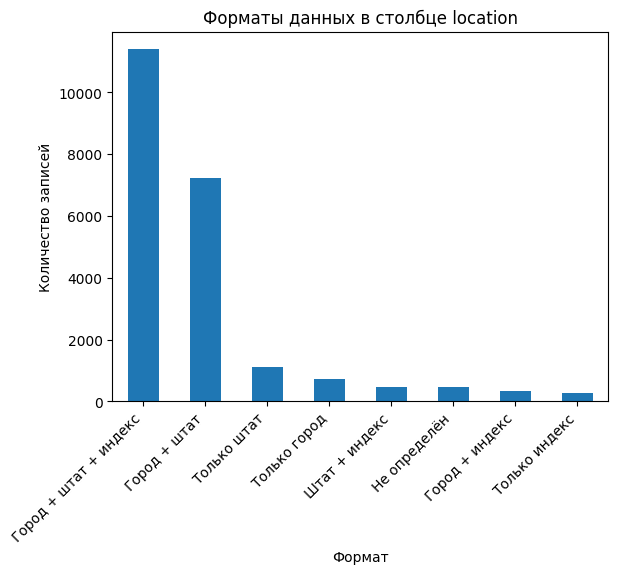

,count
Город + штат + индекс,11390
Город + штат,7235
Только штат,1105
Только город,721
Штат + индекс,483
Не определён,464
Город + индекс,333
Только индекс,269


In [ ]:
# PUT YOUR CODE HERE

#формат каждой строки
locations = df['location'].str.strip()

state_pattern = r'\b[A-Z]{2}\b'
zip_pattern = r'\b\d{5}\b'

has_state = locations.str.contains(state_pattern, regex=True)
has_zip = locations.str.contains(zip_pattern, regex=True)

# Убираем штат и индекс, чтобы проверить, осталось ли название города
city_part = (
    locations
    .str.replace(state_pattern, '', regex=True)
    .str.replace(zip_pattern, '', regex=True)
    .str.replace(r'[,;/\-]', ' ', regex=True)
    .str.strip()
)

has_city = (
    city_part.str.fullmatch(r"[A-Za-z .']+")
    & (city_part.str.len() > 0)
    & (city_part.str.len() <= 40)
)


#Присваивание каждой строке название формата
formats = pd.Series("Не определён", index=df.index)

formats[has_city & has_state & has_zip] = "Город + штат + индекс"
formats[has_city & has_state & ~has_zip] = "Город + штат"
formats[has_city & ~has_state & has_zip] = "Город + индекс"
formats[~has_city & has_state & has_zip] = "Штат + индекс"
formats[has_city & ~has_state & ~has_zip] = "Только город"
formats[~has_city & has_state & ~has_zip] = "Только штат"
formats[~has_city & ~has_state & has_zip] = "Только индекс"


#форматы и строим требуемую диаграмму
format_counts = formats.value_counts()

format_counts.plot(kind='bar')

plt.title("Форматы данных в столбце location")
plt.xlabel("Формат")
plt.ylabel("Количество записей")
plt.xticks(rotation=45, ha='right')
plt.show()

format_counts

#### Задание 1.2

В большей части строк удалось извлечь данные из ячейки столбца `location`, но остались и такие, где это не получилось. Вынесите в отдельный датасет записи, в которых не удалось определить формат записи информации о местоположении.

Над оставшимися строками проведите следующие преобразования:
1. Данные о местоположении разделите на 3 столбца: город, код штата, почтовый индекс.
2. Так как значения в столбце `почтовый индекс` являются пятизначными числами, проверьте, что в этом столбце нет чисел с другим количеством разрядов и что все они записаны в формате строки.

In [ ]:
# PUT YOUR CODE HERE


#Отделяем строки, где формат location определить не удалось
recognized_mask = formats != "Не определён"

unrecognized_locations = df[~recognized_mask].copy()
location_clean = df[recognized_mask].copy()

print("Количество распознанных строк:", len(location_clean))
print("Количество нераспознанных строк:", len(unrecognized_locations))


#Извлекаем код штата из location

location_clean['state'] = (
    location_clean['location']
    .str.extract(r'\b([A-Z]{2})\b', expand=False)
)


#Извлекаем пятизначный почтовый индекс

location_clean['zip_code'] = (
    location_clean['location']
    .str.extract(r'\b(\d{5})\b', expand=False)
)


#удаляем из исходной строки код штата, индекс и лишние разделители

location_clean['city'] = (
    location_clean['location']
    .str.replace(r'\b[A-Z]{2}\b', '', regex=True)
    .str.replace(r'\b\d{5}\b', '', regex=True)
    .str.replace(r'[,;/\-]', ' ', regex=True)
    .str.strip()
)


#Если после удаления штата и индекса строка пустая,
location_clean.loc[
    location_clean['city'] == '',
    'city'
] = pd.NA


#Перевод в почтовый индекс в строковый тип,
location_clean['zip_code'] = (
    location_clean['zip_code']
    .astype('string')
)


#Проверка: все найденные индексы состоят ровно из пяти цифр
invalid_zip = (
    location_clean['zip_code'].notna()
    & ~location_clean['zip_code'].str.fullmatch(r'\d{5}')
)

print("Количество некорректных почтовых индексов:", invalid_zip.sum())
print("Тип данных столбца zip_code:", location_clean['zip_code'].dtype)


#Вывод таблицы с результатом разделения location
display(
    location_clean[
        ['location', 'city', 'state', 'zip_code']
    ].head(20)
)

Количество распознанных строк: 21536
Количество нераспознанных строк: 464
Количество некорректных почтовых индексов: 0
Тип данных столбца zip_code: string


,location,city,state,zip_code
0,"Madison, WI 53702",Madison,WI,53702
1,"Madison, WI 53708",Madison,WI,53708
2,DePuy Synthes Companies is a member of Johnson...,DePuy Synthes Companies is a member of Johnson...,MA,<NA>
3,"Dixon, CA",Dixon,CA,<NA>
4,"Camphill, PA",Camphill,PA,<NA>
5,"Charlottesville, VA",Charlottesville,VA,<NA>
6,Contact name Tony Zerio,Contact name Tony Zerio,NaN,<NA>
7,"Austin, TX 73301",Austin,TX,73301
8,"Austin, TX 78746",Austin,TX,78746
9,"Chesterfield, MO",Chesterfield,MO,<NA>


#### Задание 1.3*

Рассмотрите отложенную часть выборки (ту, где не удалось данные из столбца `location` разделить на три поля) и сделайте выводы о возможности извлечь из данных город, код штата и почтовый индекс. Извлеките все, что возможно. Что невозможно – оставьте пустым.

In [ ]:
# PUT YOUR CODE HERE

location_restored = unrecognized_locations.copy()


#Код штата.
state_codes = (
    r'AL|AK|AZ|AR|CA|CO|CT|DE|FL|GA|HI|ID|IL|IN|IA|KS|KY|LA|'
    r'ME|MD|MA|MI|MN|MS|MO|MT|NE|NV|NH|NJ|NM|NY|NC|ND|OH|OK|'
    r'OR|PA|RI|SC|SD|TN|TX|UT|VT|VA|WA|WV|WI|WY|DC'
)

location_restored['state'] = (
    location_restored['location']
    .str.extract(rf'\b({state_codes})\b', expand=False)
)


#Пятизначный почтовый индекс
location_restored['zip_code'] = (
    location_restored['location']
    .str.extract(r'\b(\d{5})\b', expand=False)
    .astype('string')
)


#город
city_candidate = (
    location_restored['location']
    .str.replace(rf'\b({state_codes})\b', '', regex=True)
    .str.replace(r'\b\d{5}\b', '', regex=True)
    .str.replace(r'[,;/\-]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

valid_city = (
    city_candidate.str.fullmatch(r"[A-Za-z .']+")
    & (city_candidate.str.len() > 0)
    & (city_candidate.str.len() <= 40)
)

location_restored['city'] = city_candidate.where(valid_city, pd.NA)


#Сколько значений удалось восстановить
print("Удалось определить город:", location_restored['city'].notna().sum())
print("Удалось определить штат:", location_restored['state'].notna().sum())
print("Удалось определить почтовый индекс:", location_restored['zip_code'].notna().sum())


#Таблица с результатами восстановления данных
display(
    location_restored[
        ['location', 'city', 'state', 'zip_code']
    ].head(20)
)

Удалось определить город: 0
Удалось определить штат: 0
Удалось определить почтовый индекс: 0


,location,city,state,zip_code
188,"Location: Spokane, WAOverview: Responsible fo...",<NA>,NaN,<NA>
232,Location:,<NA>,NaN,<NA>
268,Location:,<NA>,NaN,<NA>
298,Phone 1-800-405-5591,<NA>,NaN,<NA>
312,Bojangles’ is expanding and opening new locati...,<NA>,NaN,<NA>
349,Contact name Jim Stein Phone 541-408-9838 Fax ...,<NA>,NaN,<NA>
357,Location(s):,<NA>,NaN,<NA>
391,Contact name BAPTIST EYE SURGEONS PLLC noname,<NA>,NaN,<NA>
674,Part Time Deputy Judicial Marshal - Belfast,<NA>,NaN,<NA>
708,Company Overview:The ADT Corporation (NYSE: AD...,<NA>,NaN,<NA>


### Задание 2

В задании 2 необходимо провести обработку столбца `salary`.

#### Задание 2.1

В столбце `salary`, как и в `location`, данные не стандатизированы. В нем в основном можно встретить записи в следующих форматах:

* 10.00 - 20.00 &dollar; &sol;hour
* 10,000.00 - 20,000.00 &dollar; &sol;year
* &dollar;10.00 &sol;hour
* &dollar;10,000.00+ &sol;year
* Up to &dollar;20,000.00

Основные проблемы, которые стоит учесть при обработке форматов:
- В каждом из форматов может быть или не быть знака доллара.
- Может отсутствовать информация о периоде, за который указывается зарплата (`/hour` или `/year` в примерах).
- Зарплата может быть указана за месяц (`/month`) и за неделю (`/week`).
- В начале, конце и середине некоторых строк есть лишние пробелы, которые не стоит учитывать.

**Задание:**
1. Определите весь перечень встречающихся форматов и напишите одно или несколько регулярных выражений для их поиска.
2. Покажите на столбчатой диаграмме количество записей, содержащих каждый из форматов. Сделайте выводы.

,Количество записей
Диапазон,2383
Не определён,818
От указанной суммы,139
До указанной суммы,100
Одна сумма,6


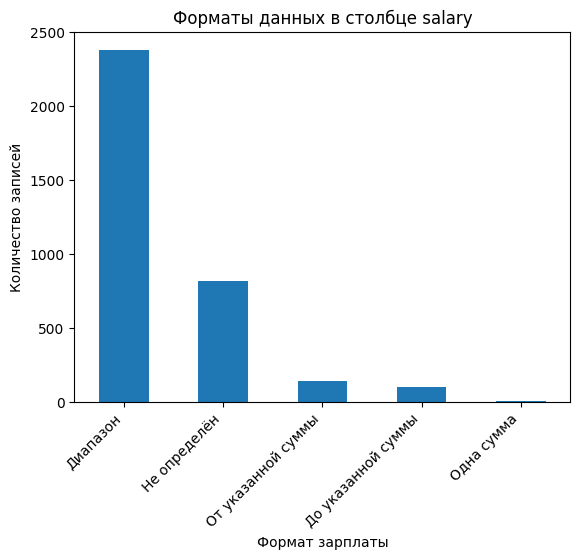

In [ ]:
# PUT YOUR CODE HERE

#Удаление лишних пробелыов
salary_data = (
    df['salary']
    .dropna()
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)

number_pattern = r'\$?\s*\d[\d,]*(?:\.\d+)?'
period_pattern = r'(?:\s*\$?\s*/\s*(?:hour|year|month|week))?'


#Основные форматы зарплаты
patterns = {
    "Диапазон": rf'^{number_pattern}\s*-\s*{number_pattern}{period_pattern}$',

    "От указанной суммы": rf'^{number_pattern}\s*\+{period_pattern}$',

    "До указанной суммы": rf'^Up\s+to\s+{number_pattern}{period_pattern}$',

    "Одна сумма": rf'^{number_pattern}{period_pattern}$'
}


#формат
salary_formats = pd.Series(
    "Не определён",
    index=salary_data.index
)

for format_name, pattern in patterns.items():
    mask = salary_data.str.fullmatch(
        pattern,
        case=False,
        na=False
    )

    salary_formats[mask] = format_name


#Количество записей каждого формата
salary_format_counts = salary_formats.value_counts()

display(
    salary_format_counts
    .rename("Количество записей")
    .to_frame()
)


#Столбчатая диаграмма
salary_format_counts.plot(kind='bar')

plt.title("Форматы данных в столбце salary")
plt.xlabel("Формат зарплаты")
plt.ylabel("Количество записей")
plt.xticks(rotation=45, ha='right')
plt.show()

#### Задание 2.2

1. Разделите столбец `salary` зарплаты три: `минимальная граница зарплаты`, `максимальная граница зарплаты`, `период`. Если значение суммы указано только одно, считайте, что это минимальная зарплата. Значение суммы в обоих столбцах преобразуйте в формат `float`.
2. Покажите на столбчатой диаграмме с группировкой среднюю и медианную минимальную зарплату в каждом периоде. Сделайте выводы.

,salary,min_salary,max_salary,period
13,9.00 - 13.00 $ /hour,9.0,13.0,hour
14,"80,000.00 - 95,000.00 $ /year",80000.0,95000.0,year
19,"60,000.00 - 72,000.00 $ /year",60000.0,72000.0,year
29,"70,000.00 - 100,000.00 $ /year",70000.0,100000.0,year
30,62.00 - 81.00 $ /hour,62.0,81.0,hour
32,"75,000.00 - 100,000.00 $ /year",75000.0,100000.0,year
36,"68,000.00 - 72,000.00 $ /year",68000.0,72000.0,year
41,"58,000.00 - 65,000.00 $ /year",58000.0,65000.0,year
42,Up to $32000.00,32000.0,NaN,NaN
43,15.00 - 16.00 $ /hour,15.0,16.0,hour


,Средняя зарплата,Медианная зарплата
period,,
hour,202.189231,15.66
month,6113.934375,4902.61
week,662.400000,600.00
year,59966.320180,60000.00


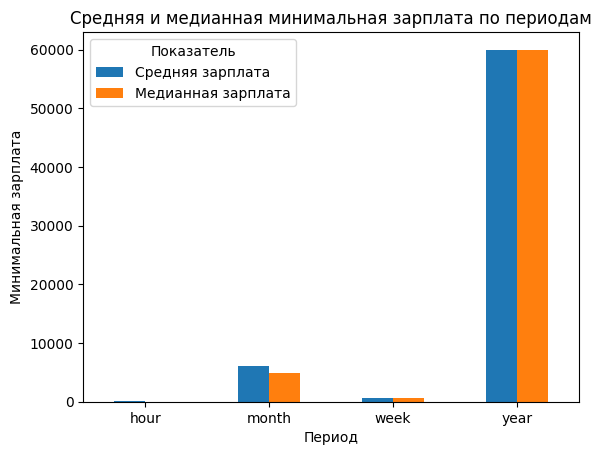

In [ ]:
# PUT YOUR CODE HERE
import re

#строки, формат salary
recognized_salary = salary_formats != "Не определён"

salary_clean = df.loc[
    salary_formats[recognized_salary].index
].copy()


#первая и вторая денежные суммы.
salary_values = salary_clean['salary'].str.extract(
    r'\$?\s*(?:Up\s+to\s+)?'
    r'(?P<min_salary>\d[\d,]*(?:\.\d+)?)'
    r'(?:\s*-\s*\$?\s*(?P<max_salary>\d[\d,]*(?:\.\d+)?))?',
    flags=re.IGNORECASE
)

salary_clean['min_salary'] = salary_values['min_salary']
salary_clean['max_salary'] = salary_values['max_salary']


#период выплаты:сhour, week, month или year.
salary_clean['period'] = (
    salary_clean['salary']
    .str.extract(
        r'/\s*(hour|week|month|year)',
        flags=re.IGNORECASE,
        expand=False
    )
    .str.lower()
)


#Удаление запятых из денежных сумм и переводим их в float.
salary_clean['min_salary'] = (
    salary_clean['min_salary']
    .str.replace(',', '', regex=False)
    .astype(float)
)

salary_clean['max_salary'] = (
    salary_clean['max_salary']
    .str.replace(',', '', regex=False)
    .astype(float)
)


#таблицв с результатом разделения salary
display(
    salary_clean[
        ['salary', 'min_salary', 'max_salary', 'period']
    ].head(20)
)


#для каждого периода средняя и медианнкя минимальная зарплата
salary_statistics = (
    salary_clean
    .dropna(subset=['period'])
    .groupby('period')['min_salary']
    .agg(['mean', 'median'])
)

salary_statistics.columns = [
    'Средняя зарплата',
    'Медианная зарплата'
]

display(salary_statistics)


#группированная столбчатая диаграмма
salary_statistics.plot(kind='bar')

plt.title("Средняя и медианная минимальная зарплата по периодам")
plt.xlabel("Период")
plt.ylabel("Минимальная зарплата")
plt.xticks(rotation=0)
plt.legend(title="Показатель")
plt.show()

#### Задание 2.3

Как было отмечено в задании 2.1, период, за который указывается зарплата, может отсутствовать. Восполните этот пробел в данных следующим образом:

1. Определите диапазон изменения (разброс) значений денежной суммы за каждый из встречающихся в данных периодов. Постройте гистограмму для каждого периода.
2. Определите, к среднему значению за какой период ближе всего сумма, у которой период не указан. Укажите для найденный период. В спорных случаях, где сумма одинаково близка к нескольким диапазонам, не выбирайте ничего.

,Минимальное значение,Максимальное значение,Среднее значение
period,,,
hour,0.0,100000.00,202.189231
month,1800.0,17688.94,6113.934375
week,12.0,1100.00,662.400000
year,0.0,850000.00,59966.320180


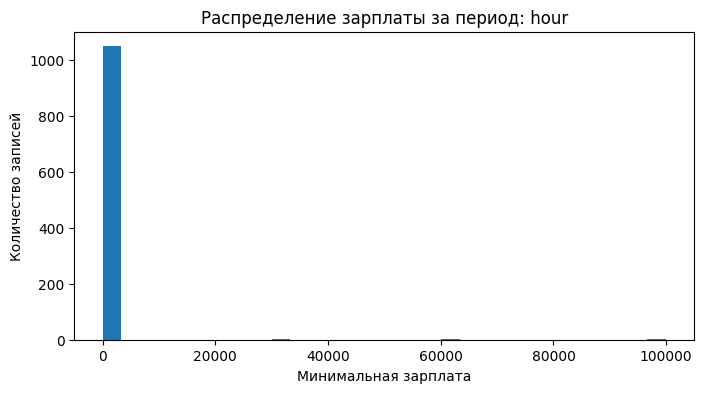

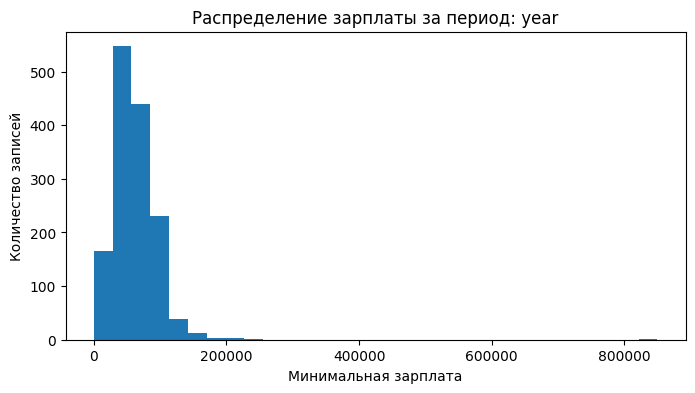

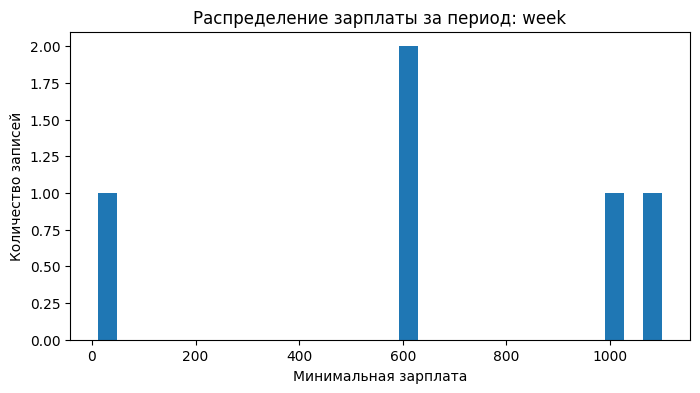

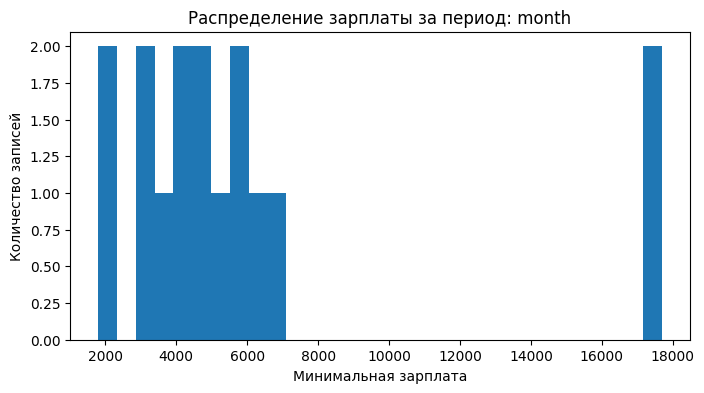

Количество оставшихся строк без периода: 0


,salary,min_salary,max_salary,period
13,9.00 - 13.00 $ /hour,9.0,13.0,hour
14,"80,000.00 - 95,000.00 $ /year",80000.0,95000.0,year
19,"60,000.00 - 72,000.00 $ /year",60000.0,72000.0,year
29,"70,000.00 - 100,000.00 $ /year",70000.0,100000.0,year
30,62.00 - 81.00 $ /hour,62.0,81.0,hour
32,"75,000.00 - 100,000.00 $ /year",75000.0,100000.0,year
36,"68,000.00 - 72,000.00 $ /year",68000.0,72000.0,year
41,"58,000.00 - 65,000.00 $ /year",58000.0,65000.0,year
42,Up to $32000.00,32000.0,NaN,month
43,15.00 - 16.00 $ /hour,15.0,16.0,hour


In [ ]:
# PUT YOUR CODE HERE

#минимальное, максимальное и среднее значение минимальной зарплаты для каждого периода
period_statistics = (
    salary_clean
    .dropna(subset=['period'])
    .groupby('period')['min_salary']
    .agg(['min', 'max', 'mean'])
)

display(
    period_statistics.rename(columns={
        'min': 'Минимальное значение',
        'max': 'Максимальное значение',
        'mean': 'Среднее значение'
    })
)


#отдельная гистограмма распределения зарплаты
for period in salary_clean['period'].dropna().unique():

    period_data = salary_clean.loc[
        salary_clean['period'] == period,
        'min_salary'
    ].dropna()

    plt.figure(figsize=(8, 4))
    plt.hist(period_data, bins=30)

    plt.title(f"Распределение зарплаты за период: {period}")
    plt.xlabel("Минимальная зарплата")
    plt.ylabel("Количество записей")
    plt.show()


#сохранение средней зарплаты для каждрго известного периода

period_means = (
    salary_clean
    .dropna(subset=['period'])
    .groupby('period')['min_salary']
    .mean()
)


#функция определяет, к среднему значению какого периода
def find_closest_period(value):

    distances = (period_means - value).abs()
    min_distance = distances.min()

    closest_periods = distances[
        distances == min_distance
    ].index.tolist()


    if len(closest_periods) != 1:
        return pd.NA

    return closest_periods[0]


#строки, где сумма известна, а период отсутствует

missing_period_mask = (
    salary_clean['period'].isna()
    & salary_clean['min_salary'].notna()
)


#отсутствующий период ближайшим по средней зарплате

salary_clean.loc[
    missing_period_mask,
    'period'
] = salary_clean.loc[
    missing_period_mask,
    'min_salary'
].apply(find_closest_period)


#результат восстановления периодов
print(
    "Количество оставшихся строк без периода:",
    salary_clean['period'].isna().sum()
)

display(
    salary_clean[
        ['salary', 'min_salary', 'max_salary', 'period']
    ].head(20)
)

### Задание 3

В задании 3 необходимо провести обработку столбца `job_type`. Выясните, какие форматы значений есть в столбце `job_type`. Сделайте выводы. При необходимости – стройте графики.

,Количество записей
job_type,
Full Time,6757
Full Time Employee,6617
"Full Time, Employee",3360
Пропуск,1628
Full Time Temporary/Contract/Project,1062
"Full Time, Temporary/Contract/Project",533
"Full Time , Employee",406
Part Time Employee,382
Part Time,329


,job_type,job_type_clean,employment_fullness,employment_type
0,Full Time Employee,Full Time Employee,Full Time,Employee
1,Full Time,Full Time,Full Time,Employee
2,"Full Time, Employee","Full Time, Employee",Full Time,Employee
3,Full Time,Full Time,Full Time,Employee
4,Full Time Employee,Full Time Employee,Full Time,Employee
5,Full Time Employee,Full Time Employee,Full Time,Employee
6,"Full Time, Employee","Full Time, Employee",Full Time,Employee
7,Full Time Employee,Full Time Employee,Full Time,Employee
8,Part Time Employee,Part Time Employee,Part Time,Employee
9,NaN,<NA>,Full Time,Employee


employment_type,/ > Employee,/ Employee,/ Temporary/Contract/Project,Employee,Exempt,Intern,Job Type,Job Type Employee,Job Type Temporary/Contract/Project,Job Type Employee,Seasonal,Temporary/Contract/Project
employment_fullness,,,,,,,,,,,,
Full Time,1,134,1,18930,1,5,2,19,2,1,0,1844
Part Time,0,2,16,912,0,3,0,2,0,0,17,41
Per Diem,0,0,0,63,0,0,0,0,0,0,0,4


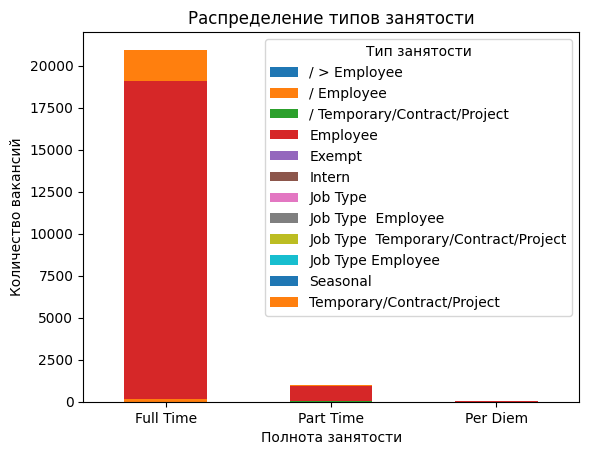

In [ ]:
# PUT YOUR CODE HERE

job_type_counts = (
    df['job_type']
    .fillna('Пропуск')
    .value_counts()
)

display(
    job_type_counts
    .rename('Количество записей')
    .to_frame()
)


#приведение записи к единому формату:
job_type_clean = (
    df['job_type']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'\s*,\s*', ', ', regex=True)
)

#полнота занятости:
fullness_pattern = r'\b(Full Time|Part Time|Per Diem)\b'

job_type_result = pd.DataFrame({
    'job_type': df['job_type'],
    'job_type_clean': job_type_clean
})

job_type_result['employment_fullness'] = (
    job_type_clean
    .str.extract(fullness_pattern, expand=False)
)


#тип занятости.
job_type_result['employment_type'] = (
    job_type_clean
    .str.replace(fullness_pattern, '', regex=True)
    .str.replace(r'^[,\s]+|[,\s]+$', '', regex=True)
)

job_type_result['employment_type'] = (
    job_type_result['employment_type']
    .replace('', pd.NA)
)


#заполняем отсутствующие данные:
job_type_result['employment_fullness'] = (
    job_type_result['employment_fullness']
    .fillna('Full Time')
)

job_type_result['employment_type'] = (
    job_type_result['employment_type']
    .fillna('Employee')
)


#Таблица с результатом обработки
display(
    job_type_result[
        [
            'job_type',
            'job_type_clean',
            'employment_fullness',
            'employment_type'
        ]
    ].head(20)
)


#Данные для стековой столбчатой диаграммы:
job_type_plot = pd.crosstab(
    job_type_result['employment_fullness'],
    job_type_result['employment_type']
)

display(job_type_plot)


#стековая столбчатач диаграмма
job_type_plot.plot(
    kind='bar',
    stacked=True
)

plt.title("Распределение типов занятости")
plt.xlabel("Полнота занятости")
plt.ylabel("Количество вакансий")
plt.xticks(rotation=0)
plt.legend(title="Тип занятости")
plt.show()

Вы заметили, что многие значения фактически одинаковые, но немного по-разному отформатированы? Приведем их к единому формату.

In [ ]:
# PUT YOUR CODE HERE

#значения job_type к единому формату

job_type_clean = (
    df['job_type']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'\s*,\s*', ', ', regex=True)
    .str.replace(
        r'^(Full Time|Part Time|Per Diem)\s*,?\s*(.+)$',
        r'\1, \2',
        regex=True
    )
)

#получившиеся варианты значений

display(
    job_type_clean
    .value_counts(dropna=False)
    .rename('Количество записей')
    .to_frame()
)

,Количество записей
job_type,
"Full Time, Employee",10384
Full Time,6771
"Full Time, Temporary/Contract/Project",1651
<NA>,1628
"Part Time, Employee",582
Part Time,330
Temporary/Contract/Project,193
Employee,147
"Full Time, / Employee",134


Столбец `job_type` состоит из двух частей: "полнота" занятости (`Full Time`, `Part Time`, `Per Diem`) и "тип" занятости (`Employee`, `Intern`). Кроме того, встречаются и неполные записи.

Задание:
1. Написать одно или несколько регулярных выражений для разделения столбца `job_type` на два: `полнота занятости`, `тип занятости`.
2. Если данные о полноте отсутствуют, внесите значение `Full Time`.
Если отсутствуют данные о типе – внесите `Employee`.
3. Постройте столбчатую диаграмму со стековой группировкой для полноты и типа занятости. Сделайте выводы.

,job_type,employment_fullness,employment_type
0,Full Time Employee,Full Time,Employee
1,Full Time,Full Time,Employee
2,"Full Time, Employee",Full Time,Employee
3,Full Time,Full Time,Employee
4,Full Time Employee,Full Time,Employee
5,Full Time Employee,Full Time,Employee
6,"Full Time, Employee",Full Time,Employee
7,Full Time Employee,Full Time,Employee
8,Part Time Employee,Part Time,Employee
9,NaN,Full Time,Employee


employment_type,/ > Employee,/ Employee,/ Temporary/Contract/Project,Employee,Exempt,Intern,Job Type,Job Type Employee,Job Type Temporary/Contract/Project,Job Type Employee,Seasonal,Temporary/Contract/Project
employment_fullness,,,,,,,,,,,,
Full Time,1,134,1,18930,1,5,2,19,2,1,0,1844
Part Time,0,2,16,912,0,3,0,2,0,0,17,41
Per Diem,0,0,0,63,0,0,0,0,0,0,0,4


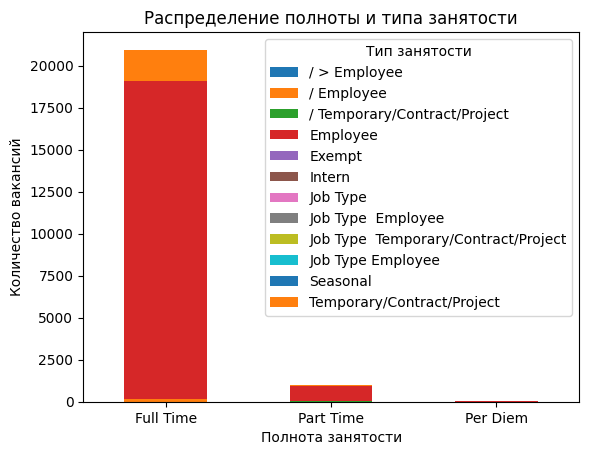

In [ ]:
# PUT YOUR CODE HERE

#Извлечение Full Time, Part Time или Per Diem
employment_fullness = job_type_clean.str.extract(
    r'\b(Full Time|Part Time|Per Diem)\b',
    expand=False
)

employment_type = (
    job_type_clean
    .str.replace(
        r'\b(Full Time|Part Time|Per Diem)\b',
        '',
        regex=True
    )
    .str.replace(r'^[,\s]+|[,\s]+$', '', regex=True)
    .replace('', pd.NA)
)


employment_fullness = employment_fullness.fillna('Full Time')

employment_type = employment_type.fillna('Employee')


#таблица с результатами

job_type_result = pd.DataFrame({
    'job_type': df['job_type'],
    'employment_fullness': employment_fullness,
    'employment_type': employment_type
})

display(job_type_result.head(20))


#сочетания полноты и типа занятости
job_type_plot = pd.crosstab(
    job_type_result['employment_fullness'],
    job_type_result['employment_type']
)

display(job_type_plot)


#столбчатая диаграмму со стековой группировкой
job_type_plot.plot(
    kind='bar',
    stacked=True
)

plt.title("Распределение полноты и типа занятости")
plt.xlabel("Полнота занятости")
plt.ylabel("Количество вакансий")
plt.xticks(rotation=0)
plt.legend(title="Тип занятости")
plt.show()

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения всех заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой решение задачи на обработку данных лабораторной работы, меньшее по объему, но сопоставимое по сложности тем заданиям, которые требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. В столбце `sector` часто представлены данные из столбца `organization` и наоборот. Устраните эту проблему.
2. В столбце `job_title` часто можно частично или полностью встретить указание местоположения организации. Сравните, совпадают ли в таких случаях данные с тем, что указано в столбцах `город`, `код штата`, `почтовый индекс`. Если в этих трех столбцах данные отсутствуют, заполните их данными из столбца `job_title`.
3. Практически во всех столбцах датасета вместо соответствующих названию данных иногда встречается текст из `job_description`. Найдите такие столбцы и записи с описанием вакансии в них. Покажите на столбчатой диаграмме, в каких столбцах и в каком количестве находится информация из столбца `job_description`.

# Дополнительные материалы

1. DAMA-DMBOK: Свод знаний по управлению данными: Второе издание / DAMA International; [пер. с англ.]. – Москва: ООО "Олимп-Бизнес", 2021. – 828 с.
2. Макгрегор, С. Обработка данных на Python: Data Wrangling и Data Quality: [Текст] / С. Макгрегор. – Москва: БХВ, 2024. – 432 с.